In [1]:
import pandas as pd
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score
)

In [2]:
df_train = pd.read_csv('train_processed_onboarding.csv', sep=',')
df_test  = pd.read_csv('test_processed_onboarding.csv',  sep=',')

print("Shape train :", df_train.shape)
print("Shape test  :", df_test.shape)
print("\nKolom:", df_train.columns.tolist())
print("\nSample train:")
print(df_train.head(3))
print("\nDistribusi risk_label (train):")
print(df_train['risk_label'].value_counts())
print("\nDistribusi risk_label (test):")
print(df_test['risk_label'].value_counts())

Shape train : (15910, 36)
Shape test  : (3978, 36)

Kolom: ['Age', 'Occupation', 'City_Tier', 'penghasilan_bulanan', 'pengeluaran_tetap', 'pengeluaran_variabel', 'total_pengeluaran', 'punya_tabungan', 'jumlah_tabungan_bulan', 'punya_investasi', 'jenis_investasi', 'tujuan_keuangan', 'toleransi_rugi', 'tanggungan_keluarga', 'dti_ratio', 'saving_rate', 'disposable_ratio', 'expense_ratio', 'ceamis_score', 'SAVEHABIT', 'SELFCONTROL_1', 'SCFHORIZON', 'FINGOALS', 'toleransi_rugi_enc', 'tujuan_keuangan_enc', 'inv_deposito', 'inv_deposito_obligasi', 'inv_saham_obligasi', 'inv_saham_reksa_dana', 'inv_tidak_ada', 'occ_Professional', 'occ_Retired', 'occ_Self_Employed', 'occ_Student', 'risk_label', 'risk_label_enc']

Sample train:
   Age     Occupation City_Tier  penghasilan_bulanan  pengeluaran_tetap  \
0   54   Professional    Tier_2             97591.98           29160.10   
1   43  Self_Employed    Tier_1             11221.83            5731.76   
2   35        Retired    Tier_2            1342

In [3]:
# ══════════════════════════════════════════════════════════
# SECTION 2 — PREPROCESSING
# ══════════════════════════════════════════════════════════

def preprocess(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    # ── Konversi INR → IDR ───────────────────────────────
    kurs_inr_to_idr = 184.92 # Senin, 01 Januari 2024

    money_cols = [
        'penghasilan_bulanan',
        'pengeluaran_tetap',
        'pengeluaran_variabel',
        'total_pengeluaran'
    ]

    for col in money_cols:
        if col in df.columns:
            df[col] = df[col] * kurs_inr_to_idr

    # ── Konversi bool → int ───────────────────────────────
    bool_cols = [
        'inv_deposito', 'inv_deposito_obligasi',
        'inv_saham_obligasi', 'inv_saham_reksa_dana',
        'inv_tidak_ada', 'occ_Professional', 'occ_Retired',
        'occ_Self_Employed', 'occ_Student'
    ]
    for col in bool_cols:
        if col in df.columns:
            df[col] = df[col].astype(int)

    # ── Encode City_Tier → numerik ────────────────────────
    # Tier_1 (kota besar) = 2, Tier_2 = 1, Tier_3 = 0
    city_map = {'Tier_1': 2, 'Tier_2': 1, 'Tier_3': 0}
    df['city_tier_enc'] = df['City_Tier'].map(city_map).fillna(1)

    return df

df_train = preprocess(df_train)
df_test  = preprocess(df_test)

print("Preprocessing selesai ✅")
print("Contoh city_tier_enc:", df_train['city_tier_enc'].value_counts().to_dict())

Preprocessing selesai ✅
Contoh city_tier_enc: {1: 7992, 2: 4654, 0: 3264}


In [4]:
REMOVE_FEATURES = [
    'punya_investasi',
    'inv_deposito',
    'inv_deposito_obligasi',
    'inv_saham_obligasi',
    'inv_saham_reksa_dana',
    'inv_tidak_ada',
]

In [5]:
# ══════════════════════════════════════════════════════════
# SECTION 3 — FEATURE SELECTION & CORRELATION CHECK
# ══════════════════════════════════════════════════════════

# Feature yang dipakai
FEATURES = [
    'saving_rate',           # ✅ dari transaksi
    'dti_ratio',             # ✅ dari data hutang
    'disposable_ratio',      # ✅ dari transaksi
    'expense_ratio',         # ✅ dari transaksi
    'ceamis_score',          # ✅ dihitung dari formula

    # ── Dari transaksi & goals ────────────────────────────
    'punya_tabungan',        # ✅ dari tracking tabungan
    'jumlah_tabungan_bulan', # ✅ dari goals user

    # ── Dari onboarding (user input sekali) ───────────────
    'SAVEHABIT',             # ✅ pertanyaan onboarding
    'SELFCONTROL_1',         # ✅ pertanyaan onboarding
    'SCFHORIZON',            # ✅ pertanyaan onboarding
    'FINGOALS',              # ✅ pertanyaan onboarding
    'toleransi_rugi_enc',    # ✅ pertanyaan onboarding
    'tujuan_keuangan_enc',   # ✅ pertanyaan onboarding
    'tanggungan_keluarga',   # ✅ pertanyaan onboarding
    'Age',                   # ✅ pertanyaan onboarding
    'city_tier_enc',         # ✅ pertanyaan onboarding

    # ── Dari onboarding (occupation) ──────────────────────
    'occ_Professional',      # ✅ dari onboarding
    'occ_Retired',           # ✅ dari onboarding
    'occ_Self_Employed',     # ✅ dari onboarding
    'occ_Student',           # ✅ dari onboarding
]

TARGET = 'risk_label_enc'

print(f"Jumlah fitur: {len(FEATURES)}")

# ── Cek semua fitur ada ───────────────────────────────────
missing_feat = [f for f in FEATURES if f not in df_train.columns]
if missing_feat:
    print(f"⚠️  Fitur tidak ditemukan: {missing_feat}")
else:
    print("✅ Semua fitur tersedia")

# ── Korelasi dengan target ────────────────────────────────
print("\nKorelasi fitur dengan risk_label_enc:")
corr = df_train[FEATURES + [TARGET]].corr()[TARGET].drop(TARGET)
print(corr.abs().sort_values(ascending=False).round(4))

# ── Distribusi target ─────────────────────────────────────
label_names = ['Konservatif', 'Moderat', 'Agresif']

print("\nDistribusi train:")
vc_train = df_train[TARGET].value_counts().sort_index()
for idx, count in vc_train.items():
    print(f"  {label_names[idx]:12s} ({idx}): "
          f"{count:5d} ({count/len(df_train)*100:.1f}%)")

print("\nDistribusi test:")
vc_test = df_test[TARGET].value_counts().sort_index()
for idx, count in vc_test.items():
    print(f"  {label_names[idx]:12s} ({idx}): "
          f"{count:5d} ({count/len(df_test)*100:.1f}%)")

Jumlah fitur: 20
✅ Semua fitur tersedia

Korelasi fitur dengan risk_label_enc:
ceamis_score             0.6682
disposable_ratio         0.6489
expense_ratio            0.6489
jumlah_tabungan_bulan    0.5776
toleransi_rugi_enc       0.5656
dti_ratio                0.4815
saving_rate              0.4026
city_tier_enc            0.3513
SELFCONTROL_1            0.1792
FINGOALS                 0.1759
SCFHORIZON               0.1655
SAVEHABIT                0.1632
tanggungan_keluarga      0.1078
tujuan_keuangan_enc      0.0942
Age                      0.0653
occ_Student              0.0108
occ_Self_Employed        0.0085
occ_Retired              0.0015
occ_Professional         0.0008
punya_tabungan              NaN
Name: risk_label_enc, dtype: float64

Distribusi train:
  Konservatif  (0): 10444 (65.6%)
  Moderat      (1):  4593 (28.9%)
  Agresif      (2):   873 (5.5%)

Distribusi test:
  Konservatif  (0):  2612 (65.7%)
  Moderat      (1):  1148 (28.9%)
  Agresif      (2):   218 (5.5%)


In [6]:
# ══════════════════════════════════════════════════════════
# SECTION 4 — PERSIAPAN DATA
# ══════════════════════════════════════════════════════════

from sklearn.utils.class_weight import compute_class_weight

# ── Ambil fitur & target ──────────────────────────────────
X_train = df_train[FEATURES].values.astype(np.float32)
y_train = df_train[TARGET].values.astype(np.int32)

X_test  = df_test[FEATURES].values.astype(np.float32)
y_test  = df_test[TARGET].values.astype(np.int32)

# ── Validation split dari train (85/15) ───────────────────
from sklearn.model_selection import train_test_split

X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train,
    test_size    = 0.15,
    random_state = 42,
    stratify     = y_train
)

print(f"Train : {len(y_tr)}")
print(f"Val   : {len(y_val)}")
print(f"Test  : {len(y_test)}")

# ── Class weight ──────────────────────────────────────────
classes           = np.unique(y_tr)
class_weights     = compute_class_weight(
    class_weight = 'balanced',
    classes      = classes,
    y            = y_tr
)
class_weight_dict = dict(zip(classes, class_weights))

print("\nClass weights:")
for cls, w in class_weight_dict.items():
    print(f"  {label_names[cls]:12s}: {w:.4f}")

# ── Scaling ───────────────────────────────────────────────
scaler    = StandardScaler()
X_tr_sc   = scaler.fit_transform(X_tr)
X_val_sc  = scaler.transform(X_val)
X_test_sc = scaler.transform(X_test)

os.makedirs('artifacts_risk', exist_ok=True)
joblib.dump(scaler,   'artifacts_risk/scaler_risk.pkl')
joblib.dump(FEATURES, 'artifacts_risk/feature_columns_risk.pkl')
print("\n✅ Scaler tersimpan")

Train : 13523
Val   : 2387
Test  : 3978

Class weights:
  Konservatif : 0.5078
  Moderat     : 1.1546
  Agresif     : 6.0750

✅ Scaler tersimpan


In [7]:
# ══════════════════════════════════════════════════════════
# SECTION 5 — CUSTOM COMPONENTS
# ══════════════════════════════════════════════════════════

# ── Custom Layer ──────────────────────────────────────────
class RiskProfileAttentionLayer(tf.keras.layers.Layer):
    """
    Custom attention layer untuk Risk Profile Classifier.
    Memberi bobot adaptif pada fitur perilaku vs rasio keuangan.
    """
    def __init__(self, units=32, **kwargs):
        super(RiskProfileAttentionLayer, self).__init__(**kwargs)
        self.units = units
        self.dense = tf.keras.layers.Dense(units, activation='relu')

    def call(self, inputs):
        attention_weights = tf.nn.softmax(inputs, axis=-1)
        attended          = inputs * attention_weights
        return self.dense(attended)

    def get_config(self):
        config = super().get_config()
        config.update({"units": self.units})
        return config


# ── Custom Loss ───────────────────────────────────────────
class WeightedCrossEntropyLoss(tf.keras.losses.Loss):
    """
    Custom loss: bobot lebih tinggi untuk kelas Agresif (2)
    karena paling sedikit di data dan paling penting
    untuk dideteksi dengan benar.

    Mapping: Konservatif=0, Moderat=1, Agresif=2
    """
    def __init__(self, class_weights=None, **kwargs):
        super().__init__(**kwargs)
        if class_weights is None:
            class_weights = [1.0, 1.0, 2.0]
        self.class_weights = tf.constant(
            class_weights, dtype=tf.float32
        )

    def call(self, y_true, y_pred):
        y_true    = tf.cast(y_true, tf.int32)
        y_true_oh = tf.one_hot(y_true, depth=3)
        y_pred    = tf.clip_by_value(y_pred, 1e-7, 1.0 - 1e-7)

        # Cross entropy
        ce = -tf.reduce_sum(
            y_true_oh * tf.math.log(y_pred), axis=-1
        )

        # Bobot per kelas
        weights = tf.reduce_sum(
            y_true_oh * self.class_weights, axis=-1
        )

        return tf.reduce_mean(weights * ce)

    def get_config(self):
        config = super().get_config()
        config.update({
            "class_weights": self.class_weights.numpy().tolist()
        })
        return config


# ── Custom Callback ───────────────────────────────────────
class RiskProfileMonitor(tf.keras.callbacks.Callback):
    """
    Monitor accuracy per epoch dan simpan best epoch.
    """
    def __init__(self, val_data):
        super().__init__()
        self.val_data   = val_data
        self.best_acc   = 0.0
        self.best_epoch = 0

    def on_epoch_end(self, epoch, logs=None):
        X_val, y_val = self.val_data
        y_pred_prob  = self.model.predict(X_val, verbose=0)
        y_pred       = np.argmax(y_pred_prob, axis=1)
        acc          = np.mean(y_pred == y_val)

        marker = ""
        if acc > self.best_acc:
            self.best_acc   = acc
            self.best_epoch = epoch + 1
            marker          = " ← best"

        print(
            f"Epoch {epoch+1:3d} | "
            f"Loss: {logs['loss']:.4f} | "
            f"Val Loss: {logs['val_loss']:.4f} | "
            f"Val Acc: {acc:.4f}{marker}"
        )

    def on_train_end(self, logs=None):
        print(f"\n✅ Best epoch : {self.best_epoch}")
        print(f"✅ Best Acc   : {self.best_acc:.4f}")

In [8]:
# ══════════════════════════════════════════════════════════
# SECTION 6 — BUILD MODEL (TF FUNCTIONAL API)
# ══════════════════════════════════════════════════════════

n_features = len(FEATURES)
n_classes  = 3   # Konservatif, Moderat, Agresif

print(f"Input  : ({n_features},)")
print(f"Output : ({n_classes},)")

inputs = tf.keras.Input(
    shape=(n_features,), name="risk_profile_features"
)

# Custom attention layer
x = RiskProfileAttentionLayer(64, name="attention")(inputs)

# Block 1
x = tf.keras.layers.Dense(128, name="dense_1")(x)
x = tf.keras.layers.BatchNormalization(name="bn_1")(x)
x = tf.keras.layers.Activation("relu", name="relu_1")(x)
x = tf.keras.layers.Dropout(0.3, name="drop_1")(x)

# Block 2
x = tf.keras.layers.Dense(64, name="dense_2")(x)
x = tf.keras.layers.BatchNormalization(name="bn_2")(x)
x = tf.keras.layers.Activation("relu", name="relu_2")(x)
x = tf.keras.layers.Dropout(0.2, name="drop_2")(x)

# Block 3
x = tf.keras.layers.Dense(32, name="dense_3")(x)
x = tf.keras.layers.BatchNormalization(name="bn_3")(x)
x = tf.keras.layers.Activation("relu", name="relu_3")(x)

# Output — softmax 3 kelas
outputs = tf.keras.layers.Dense(
    n_classes,
    activation = 'softmax',
    name       = "risk_output"
)(x)

model = tf.keras.Model(
    inputs  = inputs,
    outputs = outputs,
    name    = "RiskProfileClassifier_v1"
)
model.summary()

Input  : (20,)
Output : (3,)


Model: "RiskProfileClassifier_v1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ risk_profile_features           │ (None, 20)             │             0 │
│ (InputLayer)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ attention                       │ (None, 64)             │         1,344 │
│ (RiskProfileAttentionLayer)     │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_1 (BatchNormalization)       │ (None, 128)            │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu_1 (Activation)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop_1 (Dropout)                │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_2 (BatchNormalization)       │ (None, 64)             │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu_2 (Activation)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop_2 (Dropout)                │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_3 (BatchNormalization)       │ (None, 32)             │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu_3 (Activation)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ risk_output (Dense)             │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,995 (82.01 KB)

 Trainable params: 20,547 (80.26 KB)

 Non-trainable params: 448 (1.75 KB)

In [9]:
# ══════════════════════════════════════════════════════════
# SECTION 7 — TRAINING
# ══════════════════════════════════════════════════════════

# ── TensorBoard ───────────────────────────────────────────
log_dir = "logs/risk_profile/" + \
          pd.Timestamp.now().strftime("%Y%m%d-%H%M%S")

tensorboard_cb = tf.keras.callbacks.TensorBoard(
    log_dir        = log_dir,
    histogram_freq = 1,
    write_graph    = True
)

# Aktifkan di Colab:
# %load_ext tensorboard
# %tensorboard --logdir logs/risk_profile/

# ── Compile ───────────────────────────────────────────────
model.compile(
    optimizer = tf.keras.optimizers.Adam(learning_rate=0.001),
    loss      = WeightedCrossEntropyLoss(
        class_weights=[1.0, 1.0, 2.0]
    ),
    metrics   = ['accuracy']
)

# ── Callbacks ─────────────────────────────────────────────
callbacks = [
    RiskProfileMonitor(val_data=(X_val_sc, y_val)),
    tf.keras.callbacks.EarlyStopping(
        monitor             = 'val_accuracy',
        patience            = 15,
        restore_best_weights= True,
        mode                = 'max',
        verbose             = 0
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor  = 'val_loss',
        factor   = 0.5,
        patience = 5,
        min_lr   = 1e-6,
        verbose  = 1
    ),
    tensorboard_cb,
]

# ── Training ──────────────────────────────────────────────
print("="*55)
print("TRAINING MODEL 3 — RISK PROFILE CLASSIFIER")
print("="*55)

history = model.fit(
    X_tr_sc, y_tr,
    validation_data = (X_val_sc, y_val),
    epochs          = 100,
    batch_size      = 64,
    class_weight    = class_weight_dict,
    callbacks       = callbacks,
    verbose         = 0
)

TRAINING MODEL 3 — RISK PROFILE CLASSIFIER
Epoch   1 | Loss: 0.4227 | Val Loss: 0.4420 | Val Acc: 0.8073 ← best
Epoch   2 | Loss: 0.2104 | Val Loss: 0.2165 | Val Acc: 0.9116 ← best
Epoch   3 | Loss: 0.1735 | Val Loss: 0.1217 | Val Acc: 0.9552 ← best
Epoch   4 | Loss: 0.1492 | Val Loss: 0.1142 | Val Acc: 0.9568 ← best
Epoch   5 | Loss: 0.1367 | Val Loss: 0.1017 | Val Acc: 0.9585 ← best
Epoch   6 | Loss: 0.1311 | Val Loss: 0.1091 | Val Acc: 0.9564
Epoch   7 | Loss: 0.1292 | Val Loss: 0.1044 | Val Acc: 0.9619 ← best
Epoch   8 | Loss: 0.1203 | Val Loss: 0.0883 | Val Acc: 0.9665 ← best
Epoch   9 | Loss: 0.1156 | Val Loss: 0.0952 | Val Acc: 0.9623
Epoch  10 | Loss: 0.1152 | Val Loss: 0.0983 | Val Acc: 0.9568
Epoch  11 | Loss: 0.1124 | Val Loss: 0.0993 | Val Acc: 0.9589
Epoch  12 | Loss: 0.1074 | Val Loss: 0.0847 | Val Acc: 0.9677 ← best
Epoch  13 | Loss: 0.1001 | Val Loss: 0.0888 | Val Acc: 0.9661
Epoch  14 | Loss: 0.0982 | Val Loss: 0.0890 | Val Acc: 0.9640
Epoch  15 | Loss: 0.0984 | Val Lo

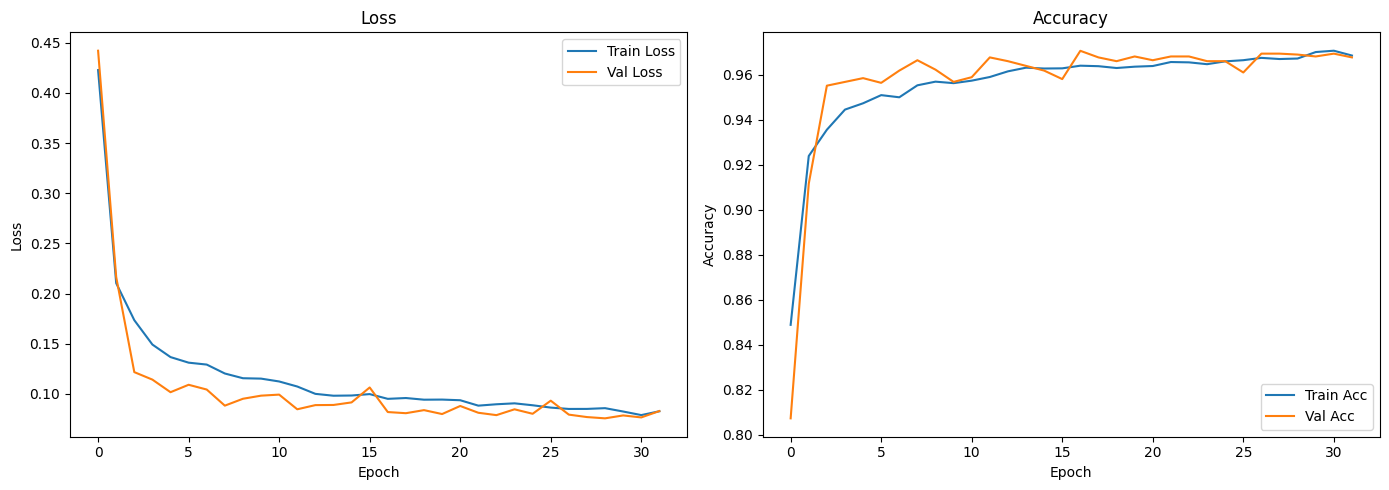

125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
HASIL EVALUASI — RISK PROFILE CLASSIFIER
Accuracy : 0.9716
Checklist Accuracy > 85%: ✅ PASS

Classification Report:
              precision    recall  f1-score   support

 Konservatif     0.9901    0.9950    0.9926      2612
     Moderat     0.9787    0.9216    0.9493      1148
     Agresif     0.7647    0.9541    0.8490       218

    accuracy                         0.9716      3978
   macro avg     0.9112    0.9569    0.9303      3978
weighted avg     0.9745    0.9716    0.9722      3978



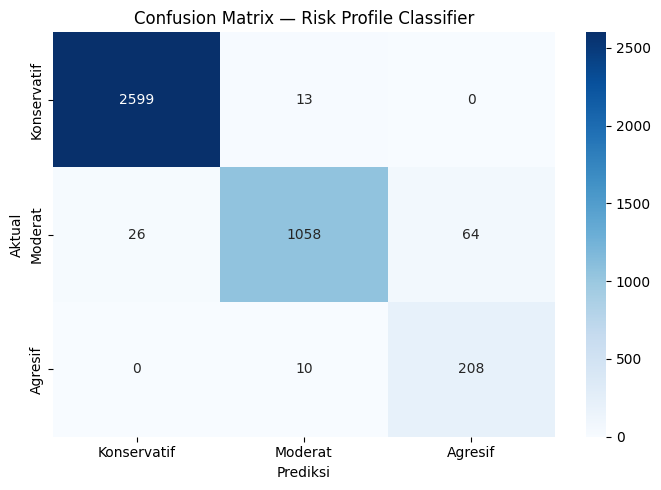


===== SAMPLE PREDICTION (10 pertama) =====
Data  1 | Aktual: Konservatif  | Prediksi: Konservatif  | Conf: 1.00 ✅
Data  2 | Aktual: Konservatif  | Prediksi: Konservatif  | Conf: 0.95 ✅
Data  3 | Aktual: Konservatif  | Prediksi: Konservatif  | Conf: 1.00 ✅
Data  4 | Aktual: Konservatif  | Prediksi: Konservatif  | Conf: 1.00 ✅
Data  5 | Aktual: Konservatif  | Prediksi: Konservatif  | Conf: 1.00 ✅
Data  6 | Aktual: Agresif      | Prediksi: Agresif      | Conf: 0.84 ✅
Data  7 | Aktual: Moderat      | Prediksi: Moderat      | Conf: 0.99 ✅
Data  8 | Aktual: Konservatif  | Prediksi: Konservatif  | Conf: 1.00 ✅
Data  9 | Aktual: Konservatif  | Prediksi: Konservatif  | Conf: 1.00 ✅
Data 10 | Aktual: Konservatif  | Prediksi: Konservatif  | Conf: 1.00 ✅


In [10]:
# ══════════════════════════════════════════════════════════
# SECTION 8 — EVALUASI
# ══════════════════════════════════════════════════════════

# ── Plot training history ─────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history['loss'],     label='Train Loss')
axes[0].plot(history.history['val_loss'], label='Val Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Loss')
axes[0].legend()

axes[1].plot(history.history['accuracy'],     label='Train Acc')
axes[1].plot(history.history['val_accuracy'], label='Val Acc')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Accuracy')
axes[1].legend()

plt.tight_layout()
plt.savefig('artifacts_risk/training_history.png')
plt.show()

# ── Prediksi di test set ──────────────────────────────────
y_pred_prob = model.predict(X_test_sc)
y_pred      = np.argmax(y_pred_prob, axis=1)
acc         = accuracy_score(y_test, y_pred)

print("="*50)
print("HASIL EVALUASI — RISK PROFILE CLASSIFIER")
print("="*50)
print(f"Accuracy : {acc:.4f}")
print(f"Checklist Accuracy > 85%: "
      f"{'✅ PASS' if acc >= 0.85 else '❌ FAIL'}")

print("\nClassification Report:")
print(classification_report(
    y_test, y_pred,
    target_names = label_names,
    digits       = 4
))

# ── Confusion Matrix ──────────────────────────────────────
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(7, 5))
sns.heatmap(
    cm,
    annot       = True,
    fmt         = 'd',
    cmap        = 'Blues',
    xticklabels = label_names,
    yticklabels = label_names
)
plt.title("Confusion Matrix — Risk Profile Classifier")
plt.ylabel("Aktual")
plt.xlabel("Prediksi")
plt.tight_layout()
plt.savefig('artifacts_risk/confusion_matrix_risk.png')
plt.show()

# ── Sample prediction ─────────────────────────────────────
print("\n===== SAMPLE PREDICTION (10 pertama) =====")
for i in range(min(10, len(y_pred))):
    actual = label_names[y_test[i]]
    pred   = label_names[y_pred[i]]
    conf   = float(y_pred_prob[i][y_pred[i]])
    status = "✅" if actual == pred else "❌"
    print(f"Data {i+1:2d} | "
          f"Aktual: {actual:12s} | "
          f"Prediksi: {pred:12s} | "
          f"Conf: {conf:.2f} {status}")

In [11]:
# ══════════════════════════════════════════════════════════
# SECTION 9 — SAVE MODEL
# ══════════════════════════════════════════════════════════

# ── Save .keras ───────────────────────────────────────────
model.save('artifacts_risk/risk_profile_v1.keras')
print("✅ Model tersimpan: artifacts_risk/risk_profile_v1.keras")

# ── Verifikasi load ───────────────────────────────────────
try:
    loaded = tf.keras.models.load_model(
        'artifacts_risk/risk_profile_v1.keras',
        custom_objects={
            'RiskProfileAttentionLayer': RiskProfileAttentionLayer,
            'WeightedCrossEntropyLoss' : WeightedCrossEntropyLoss
        }
    )
    test_out = loaded.predict(X_test_sc[:3], verbose=0)
    print("✅ Verifikasi load berhasil")
    print(f"   Output shape: {test_out.shape}")

except Exception as e:
    print(f"⚠️  Coba compile=False: {e}")
    loaded = tf.keras.models.load_model(
        'artifacts_risk/risk_profile_v1.keras',
        custom_objects={
            'RiskProfileAttentionLayer': RiskProfileAttentionLayer
        },
        compile=False
    )
    loaded.compile(
        optimizer = tf.keras.optimizers.Adam(0.001),
        loss      = WeightedCrossEntropyLoss([1.0, 1.0, 2.0]),
        metrics   = ['accuracy']
    )
    print("✅ Load + recompile berhasil")

# ── Metadata ──────────────────────────────────────────────
metadata = {
    "model_name"    : "RiskProfileClassifier_v1",
    "model_type"    : "classification",
    "features"      : FEATURES,
    "n_features"    : len(FEATURES),
    "n_classes"     : 3,
    "target"        : "risk_label_enc",
    "label_map"     : {
        "Konservatif": 0,
        "Moderat"    : 1,
        "Agresif"    : 2
    },
    "label_names"   : label_names,
    "accuracy_test" : round(float(acc), 4),
    "checklist_pass": bool(acc >= 0.85),
    "log_dir"       : log_dir,
}
joblib.dump(metadata, 'artifacts_risk/metadata_risk.pkl')

print("\n✅ Semua artifact tersimpan:")
for f in os.listdir('artifacts_risk'):
    size = os.path.getsize(f'artifacts_risk/{f}')
    print(f"   {f:40s} {size:>10,} bytes")

✅ Model tersimpan: artifacts_risk/risk_profile_v1.keras


/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:424: UserWarning: `build()` was called on layer 'attention', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(


✅ Verifikasi load berhasil
   Output shape: (3, 3)

✅ Semua artifact tersimpan:
   metadata_risk.pkl                               648 bytes
   scaler_risk.pkl                               1,095 bytes
   training_history.png                         59,580 bytes
   risk_profile_v1.keras                       318,422 bytes
   feature_columns_risk.pkl                        339 bytes
   confusion_matrix_risk.png                    29,826 bytes


In [12]:
# ══════════════════════════════════════════════════════════
# SECTION 10 — DEMO GRADIENTTAPE (SIDE QUEST CHECKLIST)
# ══════════════════════════════════════════════════════════

print("="*55)
print("DEMO: Custom Training Loop (tf.GradientTape)")
print("Side Quest Checklist")
print("="*55)

# ── Demo model kecil (TERPISAH dari model utama) ──────────
demo_inputs  = tf.keras.Input(shape=(n_features,))
demo_x       = tf.keras.layers.Dense(
    32, activation='relu',
    kernel_initializer='he_normal'
)(demo_inputs)
demo_x       = tf.keras.layers.BatchNormalization()(demo_x)
demo_x       = tf.keras.layers.Dense(
    16, activation='relu',
    kernel_initializer='he_normal'
)(demo_x)
demo_outputs = tf.keras.layers.Dense(
    3, activation='softmax'
)(demo_x)

demo_model     = tf.keras.Model(demo_inputs, demo_outputs,
                                name="demo_risk_gradient_tape")
demo_optimizer = tf.keras.optimizers.Adam(learning_rate=0.0001)
demo_loss_fn   = tf.keras.losses.SparseCategoricalCrossentropy()

train_loss_m = tf.keras.metrics.Mean()
val_loss_m   = tf.keras.metrics.Mean()
train_acc_m  = tf.keras.metrics.SparseCategoricalAccuracy()

# Dataset
X_tr_f32  = X_tr_sc.astype(np.float32)
X_val_f32 = X_val_sc.astype(np.float32)
y_tr_i32  = y_tr.astype(np.int32)
y_val_i32 = y_val.astype(np.int32)

demo_train_ds = tf.data.Dataset.from_tensor_slices(
    (X_tr_f32, y_tr_i32)
).shuffle(2000).batch(64)

demo_val_ds = tf.data.Dataset.from_tensor_slices(
    (X_val_f32, y_val_i32)
).batch(64)

@tf.function
def demo_train_step(x_batch, y_batch):
    with tf.GradientTape() as tape:
        y_pred = demo_model(x_batch, training=True)
        loss   = demo_loss_fn(y_batch, y_pred)

    grads, _ = tf.clip_by_global_norm(
        tape.gradient(loss, demo_model.trainable_variables),
        clip_norm=1.0
    )
    demo_optimizer.apply_gradients(
        zip(grads, demo_model.trainable_variables)
    )
    train_loss_m.update_state(loss)
    train_acc_m.update_state(y_batch, y_pred)

@tf.function
def demo_val_step(x_batch, y_batch):
    y_pred = demo_model(x_batch, training=False)
    loss   = demo_loss_fn(y_batch, y_pred)
    val_loss_m.update_state(loss)

# Training loop
DEMO_EPOCHS = 10
for epoch in range(DEMO_EPOCHS):
    train_loss_m.reset_state()
    val_loss_m.reset_state()
    train_acc_m.reset_state()

    for xb, yb in demo_train_ds:
        demo_train_step(xb, yb)
    for xb, yb in demo_val_ds:
        demo_val_step(xb, yb)

    t_loss = train_loss_m.result().numpy()
    v_loss = val_loss_m.result().numpy()
    t_acc  = train_acc_m.result().numpy()

    if np.isnan(t_loss):
        print(f"⚠️  NaN di epoch {epoch+1}")
        break

    print(
        f"Demo Epoch {epoch+1:2d} | "
        f"Train Loss: {t_loss:.4f} | "
        f"Val Loss: {v_loss:.4f} | "
        f"Train Acc: {t_acc:.4f}"
    )

print("\n✅ Demo GradientTape selesai!")
print("   Model production: artifacts_risk/risk_profile_v1.keras")
print("   Demo model ini  : tidak disimpan")

DEMO: Custom Training Loop (tf.GradientTape)
Side Quest Checklist
Demo Epoch  1 | Train Loss: 1.1411 | Val Loss: 0.8830 | Train Acc: 0.4221
Demo Epoch  2 | Train Loss: 0.7426 | Val Loss: 0.5915 | Train Acc: 0.6630
Demo Epoch  3 | Train Loss: 0.5416 | Val Loss: 0.4535 | Train Acc: 0.7983
Demo Epoch  4 | Train Loss: 0.4387 | Val Loss: 0.3742 | Train Acc: 0.8394
Demo Epoch  5 | Train Loss: 0.3759 | Val Loss: 0.3214 | Train Acc: 0.8584
Demo Epoch  6 | Train Loss: 0.3296 | Val Loss: 0.2823 | Train Acc: 0.8722
Demo Epoch  7 | Train Loss: 0.2943 | Val Loss: 0.2515 | Train Acc: 0.8846
Demo Epoch  8 | Train Loss: 0.2706 | Val Loss: 0.2270 | Train Acc: 0.8906
Demo Epoch  9 | Train Loss: 0.2445 | Val Loss: 0.2076 | Train Acc: 0.9023
Demo Epoch 10 | Train Loss: 0.2331 | Val Loss: 0.1916 | Train Acc: 0.9074

✅ Demo GradientTape selesai!
   Model production: artifacts_risk/risk_profile_v1.keras
   Demo model ini  : tidak disimpan
